In [83]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [84]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [85]:

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [86]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [87]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        if state == self.goal:
            return True
        else:
            return False
        

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        legal_actions = []
        row, col = state
        for action in MOVES:
            dr, dc = MOVES[action]
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        
        return legal_actions
        
        

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        row, col = state 
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        return 1
        

In [88]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [89]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [90]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

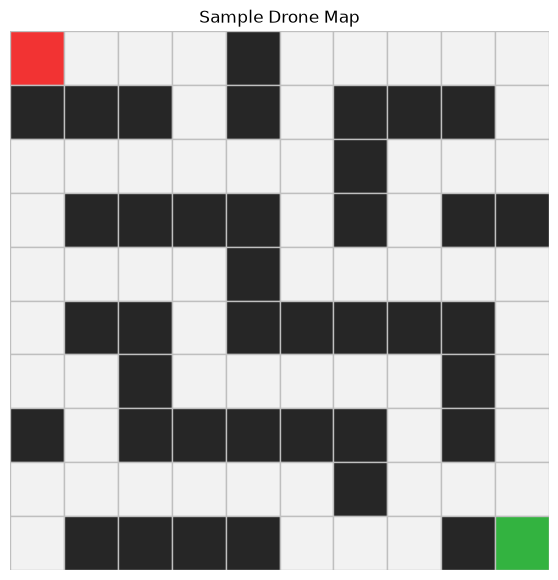

In [91]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [92]:
class SearchAlgorithm(ABC):
    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        for action in problem.actions(node.state):
            next_state = problem.result(node.state, action)
            cost = node.path_cost + problem.action_cost(node.state, action, next_state)
            yield Node(state=next_state, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [93]:
        
class BreadthFirstSearch(SearchAlgorithm):
            def search(self, problem: Problem) -> SearchResult:
                algorithm = "BFS"

                node = Node(problem.initial_state())

                if problem.is_goal(node.state):
                    return SearchResult(algorithm, "Success", node, nodes_expanded=0, max_frontier_size=1, reached_count=1)

                frontier = deque([node])
                reached = {node.state}

                nodes_expanded = 0
                max_frontier_size = 1

                while frontier:
                    node = frontier.popleft()
                    nodes_expanded += 1

                    for child in self.expand(problem, node):
                        state = child.state
                        
                        if problem.is_goal(state):
                                return SearchResult(
                                    algorithm,
                                    "Success",
                                    child,
                                    nodes_expanded,
                                    max_frontier_size,
                                    len(reached),
                                )
                        if state not in reached:
                            reached.add(state)

                            frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

                return SearchResult(
                    algorithm,
                    "Failure",
                    None,
                    nodes_expanded,
                    max_frontier_size,
                    len(reached),
                )

In [94]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        #TODO 5
        root = Node(problem.initial_state())

        if problem.is_goal(root.state):
            return SearchResult(algorithm, "Success", root, 0, 1, 1)

        frontier = [root]
        reached = {root.state}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if child.state not in reached:
                    reached.add(child.state)

                    if problem.is_goal(child.state):
                        return SearchResult(
                            algorithm,
                            "Success",
                            child,
                            nodes_expanded,
                            max_frontier_size,
                            len(reached),
                        )

                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm,
            "Failure",
            None,
            nodes_expanded,
            max_frontier_size,
            len(reached),
        )


In [95]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"
        initial_node = Node(problem.initial_state())

        metrics = {"nodes_expanded": 0, "max_stack_size": 1}

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        status = {
            "success": "Success",
            "failure": "Failure",
            "cutoff": "Cutoff",
        }[status]

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)

        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            result, status = self._recursive_dls(
                problem,
                child,
                limit,
                metrics,
                current_stack_size + 1,
            )

            if status == "success":
                return result, "success"
            if status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"

        return None, "failure"

In [96]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        dls = DepthLimitedSearch()
        total_expanded = 0
        max_frontier = 0
        iteration_log = []

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            total_expanded += result.nodes_expanded
            max_frontier = max(max_frontier, result.max_frontier_size)

            iteration_log.append({"limit": limit, "status": result.status})

            if result.status == "Success":
                return SearchResult(
                    algorithm,
                    "Success",
                    result.solution,
                    total_expanded,
                    max_frontier,
                    result.reached_count,
                    iterations=iteration_log,
                )

            if result.status == "Failure":
                return SearchResult(
                    algorithm,
                    "Failure",
                    None,
                    total_expanded,
                    max_frontier,
                    0,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm,
            "Cutoff",
            None,
            total_expanded,
            max_frontier,
            0,
            iterations=iteration_log,
        )

In [97]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18.0,18.0,50,5,52
1,DFS,Success,NaN,18.0,18.0,18,4,22
2,DLS,Cutoff,10.0,NaN,NaN,16,10,0
3,IDS,Success,NaN,18.0,18.0,356,18,0


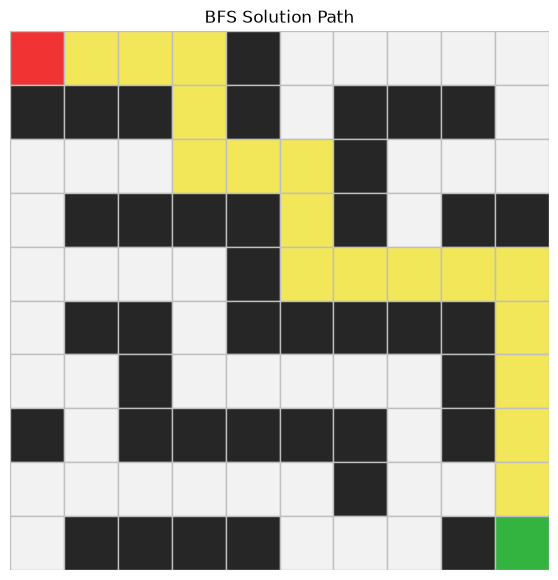

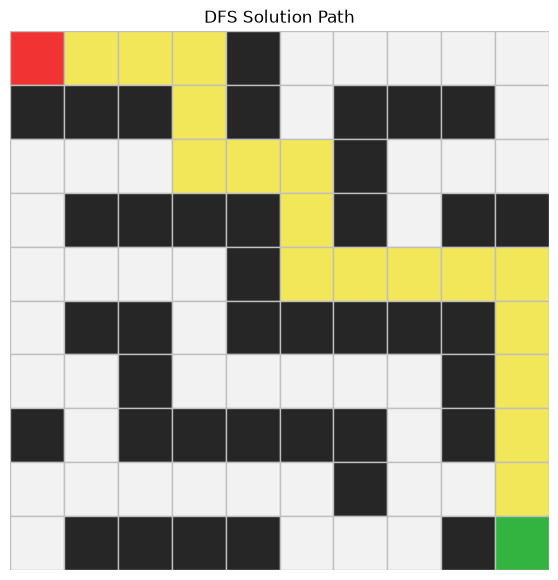

In [98]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [99]:
# TODO 10:
custom_grid_1 = [
    [0,1,0,0,0],
    [0,1,0,1,0],
    [0,1,0,1,0],
    [0,0,0,1,0],
    [0,0,0,1,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (3,4)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,13,13,16,2,16
1,DFS,Success,NaN,13,13,14,4,17
2,DLS,Success,20.0,15,15,15,15,0
3,IDS,Success,NaN,13,13,232,13,0


In [100]:
# TODO 11:
custom_grid_2 = [
    [0,0,1,0,0],
    [1,0,1,0,1],
    [0,0,0,0,1],
    [0,1,1,0,0],
    [0,0,0,1,0],
]

custom_start_2 = (0,0)
custom_goal_2 = (4,4)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,26.0,26.0,47,4,49
1,DFS,Success,NaN,26.0,26.0,36,3,39
2,DLS,Cutoff,20.0,NaN,NaN,33,20,0
3,IDS,Success,NaN,26.0,26.0,489,26,0


In [101]:
# Custom map 1: long narrow corridor
custom_grid_1 = [
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]
custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18,18,18,1,19
1,DFS,Success,NaN,18,18,18,1,20
2,DLS,Success,20.0,18,18,20,20,0
3,IDS,Success,NaN,18,18,171,18,0


Reflection Question
15.1
1. A state is the drone's current grid position, (row, col)
2. An action is a movement direction that is the 'UP','Down','left','Right'
3. The result function return the new state produced by applying that action, it's the transition model, mapping a state action pair to the resulting state.
4. The same search code works on any problem that implements the problem interface without rewriting the search logic.

15.2
1. BFS uses a FIFO queue because it must explore all nodes at depth d before any node at depth d+1.
2. Because every step costs the same, so the path with the fewest steps is also the cheapest path. Since BFS always finds the goals at the shallowest depth at which it's reachable.
3. The reached set prevents BFS from re-expanding states it ahs already discovered, avoiding infinite loops and redundant work which keeps it efficient.

15.3
1. DFS uses a stack because it commits to exploring one branch as deeply as possible before backtracking by last in first out order naturally produces the go deep first behavior
2. DFS is not guaranteed to find the shortest path because it can find a long winding solution down a branch it picked early even if a much shorter path exist elsewhere because it doesn't route by depth
3. DFS use less memory than BFS when the solution lies deep in a narrow tree, since it only needs to store one path rather than an entire frontier of nodes at a given depth
4. DFS performs badly when it dives into a deep or even infinite branch that doesn't contain the goal wasting massive effort before backtracking especially bad in graphs with cycles 

15.4
1. If the depth limit is too small then the DLS will never find a solution that lies deeper than the limit even if one exists 
2. "cutoff" means the search hit the depth boundary somewhere without having fully proven there is no solution at all
3. DLS differs from ordinary DFS in that it refuses to expand any node beyond a fixed depth bounding both its time and its risk of looping forever down an infinite branch
4. Path-cycle checking is used because DLS may legitimately need to revisit a state via a different non cyclical route within the depth bound

15.5
1. IDS repeats DLS with increasing limits because it doesn't know the solution depth ahead of time running shallow to deep guarantees it finds the shallowest successful depth without needing to choose a limit in advance. 
2. DLS with one small fixed limit is incomplete if the goal lies deeper but IDS keeps raising the limit indefinitely so eventually the limit will reach the goal's actual depth.
3. IDS only needs to store one DFS style path at a time rather than full frontier of all nodes at a given depth 
4. The cost is that shallow nodes get re-expanded on every iteration, this is the trade-off for IDS small memort footprint

15.6
1. In practice, route safety might depend on factors beyond grid distance
2. If all moves cost the same and you just want the fewest moves, BFS is the right choice, it's both complete and optimal for unit cost unweighted graphs, and simpler to reason about than IDS
3. if you want to bound how deep the drone searches, DLS is appropriate, since it explicitly enforces a maximum search depth.
4. This grid model is major simplification of real drone navigation, it ignores continuous space, drone altitude/3D movement =, dynamic obstacles turning costs, sensor uncertainty and battery consumption that varies with speed and wind all addressed more realistically by the weighted search.
